Random Sample Descriptive Stats:
count      150.000000
mean      1373.240000
std       2414.462467
min          0.000000
25%         14.500000
50%        135.500000
75%       1654.000000
max      12590.000000
Name: Value, dtype: float64
Systematic Sample Descriptive Stats:
count      28.000000
mean     1086.428571
std      1551.071563
min         0.000000
25%        41.500000
50%       158.000000
75%      2127.750000
max      4522.000000
Name: Value, dtype: float64


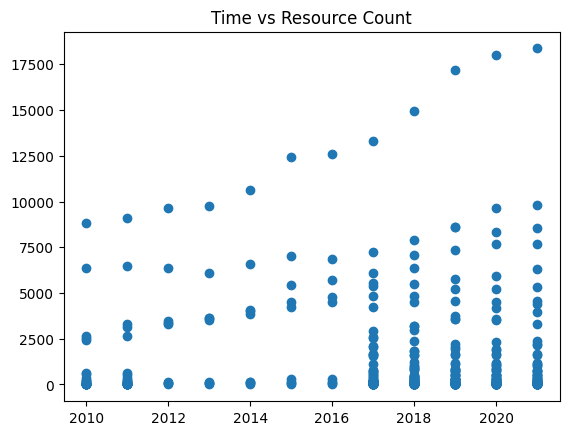

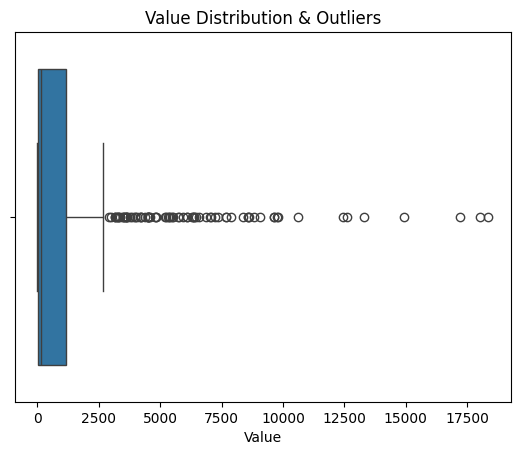

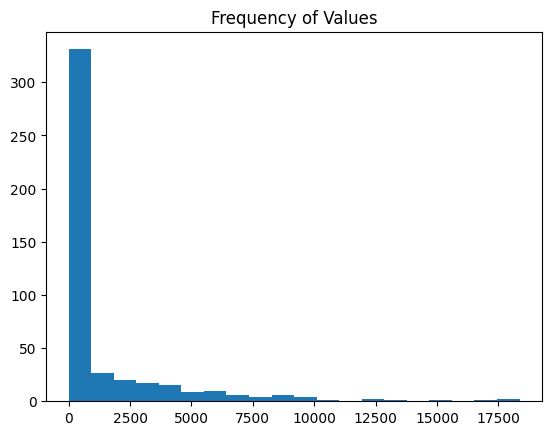

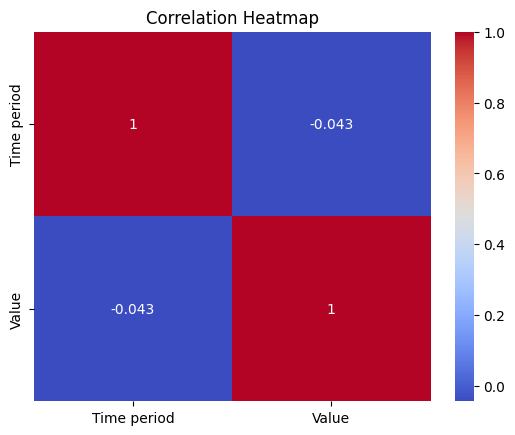

Pearson: -0.0428, Spearman: -0.0242, Chi-Square P-Value: 1.0000
T-stat: -0.1435, P-value: 0.8861
P-value > 0.05 → Sample is representative of the population.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


df = pd.read_excel('health.xlsx')

def get_descriptive_stats(sample_data, field_name):
    return sample_data[field_name].describe()

random_sample = df.sample(n=150, random_state=1)
print("Random Sample Descriptive Stats:")

print(get_descriptive_stats(random_sample, "Value"))

condition_df = df[df['Sector'] == 'Private'].reset_index(drop=True)
systematic_sample = condition_df.iloc[::5]
print("Systematic Sample Descriptive Stats:")
print(get_descriptive_stats(systematic_sample, "Value"))


plt.scatter(df['Time period'], df['Value'])
plt.title('Time vs Resource Count')
plt.show()


sns.boxplot(x=df['Value'])
plt.title('Value Distribution & Outliers')
plt.show()


plt.hist(df['Value'], bins=20)
plt.title('Frequency of Values')
plt.show()


sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


pearson_corr, _ = stats.pearsonr(df['Time period'], df['Value'])

spearman_corr, _ = stats.spearmanr(df['Time period'], df['Value'])

contingency = pd.crosstab(df['Sector'], df['Measure'])

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print(f"Pearson: {pearson_corr:.4f}, Spearman: {spearman_corr:.4f}, Chi-Square P-Value: {p_chi:.4f}")

pop_mean = df['Value'].mean()

t_stat, p_val = stats.ttest_1samp(random_sample['Value'], popmean=pop_mean)
print(f"T-stat: {t_stat:.4f}, P-value: {p_val:.4f}")

if p_val > 0.05:
    print("P-value > 0.05 → Sample is representative of the population.")
else:
    print("P-value <= 0.05 → Sample significantly differs from the population.")

D2

In [3]:
import pandas as pd
import numpy as np

df = pd.read_excel('health.xlsx')
print(df.head())
print(df.info())

   Time period Reference area    Measure      Sector  Value
0         2010            UAE  Hospitals  Government     32
1         2010            UAE  Hospitals     Private     53
2         2010            UAE  Hospitals       Total     85
3         2010            UAE       Beds  Government   6393
4         2010            UAE       Beds     Private   2436
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Time period     457 non-null    int64 
 1   Reference area  457 non-null    object
 2   Measure         457 non-null    object
 3   Sector          457 non-null    object
 4   Value           457 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 18.0+ KB
None


In [4]:

print(df.isnull().sum())

df['Value'] = df['Value'].fillna(df['Value'].mean())

df.drop_duplicates(inplace=True)

Time period       0
Reference area    0
Measure           0
Sector            0
Value             0
dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Reference area'] = le.fit_transform(df['Reference area'])
df['Measure'] = le.fit_transform(df['Measure'])
df['Sector'] = le.fit_transform(df['Sector'])

In [6]:
from sklearn.model_selection import train_test_split

X = df[['Time period', 'Reference area', 'Measure', 'Sector']]
y = df['Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Elastic Net': ElasticNet(),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {'MSE': mean_squared_error(y_test, preds), 'R2': r2_score(y_test, preds)}

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
preds_poly = lr_poly.predict(X_test_poly)
results['Polynomial (deg 2)'] = {'MSE': mean_squared_error(y_test, preds_poly), 'R2': r2_score(y_test, preds_poly)}

results_df = pd.DataFrame(results).T
print(results_df)
best_model_name = results_df['R2'].idxmax()
print(f"\nBest Model: {best_model_name}")

                             MSE        R2
Linear Regression   3.225132e+06  0.437167
Ridge               3.223624e+06  0.437431
Lasso               3.224355e+06  0.437303
Elastic Net         3.356572e+06  0.414229
Polynomial (deg 2)  1.909561e+06  0.666754

Best Model: Polynomial (deg 2)


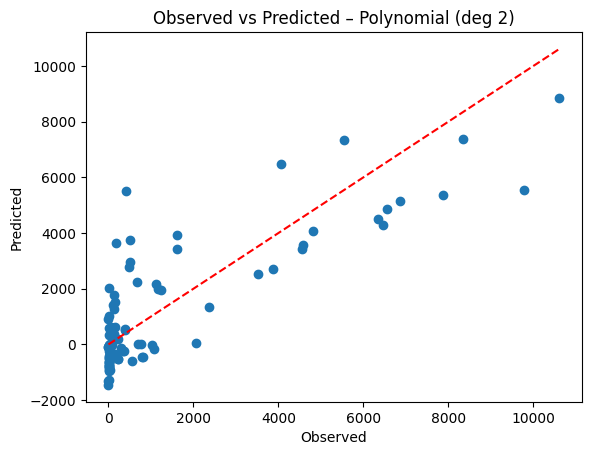

In [9]:

if best_model_name == 'Polynomial (deg 2)':
    best_preds = preds_poly
else:
    best_preds = models[best_model_name].predict(X_test)

plt.scatter(y_test, best_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Observed')
plt.ylabel('Predicted')
plt.title(f'Observed vs Predicted – {best_model_name}')
plt.savefig('regression_scatter.png')
plt.show()

In [10]:

if best_model_name == 'Polynomial (deg 2)':
    print("Intercept:", lr_poly.intercept_)
    print("Coefficients:", lr_poly.coef_)
else:
    best = models[best_model_name]
    print("Intercept:", best.intercept_)
    print("Coefficients:", best.coef_)

Intercept: 19.51940557507328
Coefficients: [    0.           216.36404128 -1419.8386815  -1285.53713098
   545.40199433   -81.41885319  -125.45431142   -51.63310067
   108.27606207   846.95798732  1078.32956922  -520.77378931
   325.73386892  -447.93284347   257.93197173]


Section 3

In [11]:

median_val = df['Value'].median()
df['Value_Class'] = df['Value'].apply(lambda x: 'High' if x >= median_val else 'Low')
y_class = df['Value_Class']

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

le2 = LabelEncoder()
y_class_enc = le2.fit_transform(y_class)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class_enc, test_size=0.2, random_state=42)
X_train_cs = scaler.fit_transform(X_train_c)
X_test_cs = scaler.transform(X_test_c)

classifiers = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
}

cls_results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_cs, y_train_c)
    preds = clf.predict(X_test_cs)
    cls_results[name] = {
        'Accuracy': accuracy_score(y_test_c, preds),
        'Precision': precision_score(y_test_c, preds, average='weighted'),
        'Recall': recall_score(y_test_c, preds, average='weighted'),
        'F1': f1_score(y_test_c, preds, average='weighted'),
    }

cls_df = pd.DataFrame(cls_results).T
print(cls_df)
best_clf_name = cls_df['Accuracy'].idxmax()
print(f"\nBest Classifier: {best_clf_name}")

                     Accuracy  Precision    Recall        F1
Logistic Regression  0.847826   0.848485  0.847826  0.847754
KNN                  0.913043   0.913826  0.913043  0.913002
SVM                  0.869565   0.872381  0.869565  0.869318
Decision Tree        1.000000   1.000000  1.000000  1.000000
Random Forest        0.989130   0.989362  0.989130  0.989129

Best Classifier: Decision Tree


In [13]:
best_clf = classifiers[best_clf_name]
final_preds = best_clf.predict(X_test_cs)
unique, counts = np.unique(final_preds, return_counts=True)
print(dict(zip(le2.inverse_transform(unique), counts)))

{'High': np.int64(46), 'Low': np.int64(46)}


section 4

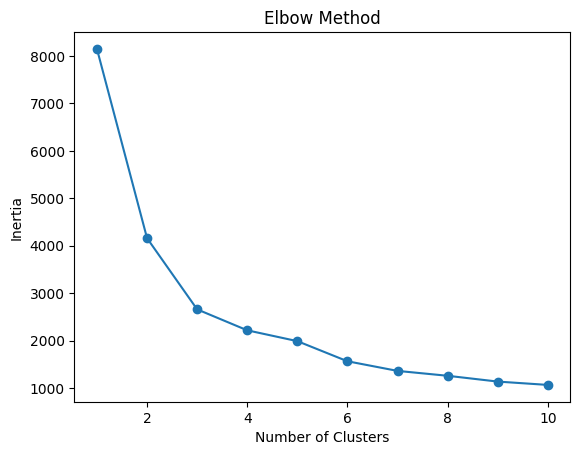

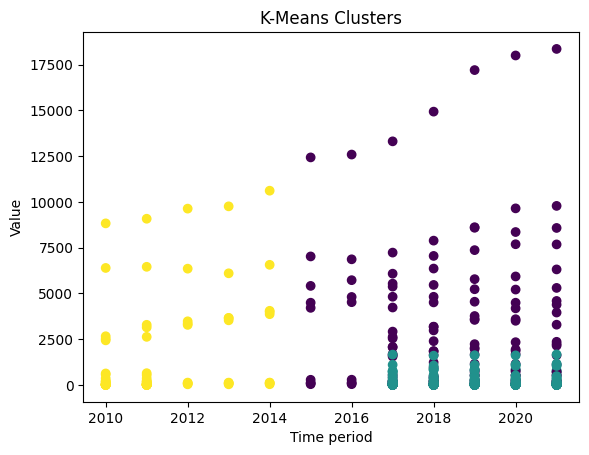

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters'); plt.ylabel('Inertia')
plt.title('Elbow Method'); plt.savefig('elbow.png'); plt.show()


optimal_k = 3
km_final = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = km_final.fit_predict(X)


plt.scatter(df['Time period'], df['Value'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Time period'); plt.ylabel('Value')
plt.title('K-Means Clusters'); plt.savefig('clusters.png'); plt.show()

In [ ]:
print(df.groupby('Cluster')[['Time period','Value']].mean())

         Time period        Value
Cluster                          
0        2018.681818  2313.934343
1        2019.022472   263.550562
2        2011.333333  1671.913580
